This code run under the Cebra conda environement on MacbookPro
Exploring the time offset with fix model architecture Offset-5 and dimensions dim=6

In [1]:
import cebra
from cebra import CEBRA
import torch
if torch.cuda.is_available():
    print('using GPU')
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    print('using MPS')
    DEVICE = "mps"
else:
    print('using CPU')
    DEVICE = "cpu"

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

using MPS


Load the data (time varying spike count of 208 neurons for one sample time section of day one of PurWhi, file created by 1_Read_one_NWB_Site.ipynb)

In [2]:
neuro_path = '/Users/elie/Library/CloudStorage/Box-Box/ManipBerkeleyZF/neuro_PurWhi_WF/'
filename = '%s/NeuralPop_activePeriod_countData_FS100.pkl' % (neuro_path)
neural_data = cebra.load_data(file=filename, key = 'neuralpop_data')
FS=100

In [3]:
print('recording duration:' + str(neural_data.shape[1]/100/60/60) + ' hrs or ' + str(neural_data.shape[1]/100/60) + ' min')
print('number of units: ' + str(neural_data.shape[0]))

recording duration:0.42083333333333334 hrs or 25.25 min
number of units: 208


Text(0.5, 1.0, 'Spike count data of 208 neurons')

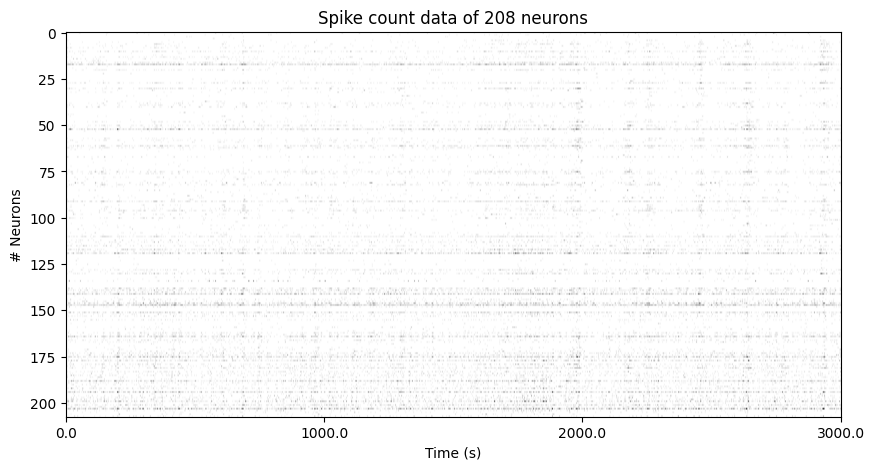

In [4]:
plt.figure(figsize=(10,5))
ax1= plt.subplot(1,1,1)
ax1.imshow(neural_data[:,:30*FS], aspect = 'auto', vmax = np.round(100*neural_data[:,:30*FS].max())/100, vmin = 0, cmap ='gray_r')
ax1.set_ylabel('# Neurons')
ax1.set_xlabel('Time (s)')
ax1.set_xticks(np.linspace(0,30*FS, 4))
ax1.set_xticklabels(np.linspace(0,30*FS, 4))
ax1.set_title('Spike count data of 208 neurons')

In [5]:
# Split data and labels into train/validation

split_idx = int(0.8 * neural_data.shape[1])
# suggestion: 5%-20% depending on your dataset size; note that this splits the
# into an early and late part, which might not be ideal for your data/experiment!
# As a more involved alternative, consider e.g. a nested time-series split.

train_data = neural_data.T[:split_idx]
valid_data = neural_data.T[split_idx:]

In [6]:
# identify indices for the first two trials in the section (note that the first 3 sec of the first trial is truncated)
Time0 = 18765 # in s
TimeEnd = 20279.99 # in s
Trial1 = [18762.33, 18768.42] # in s
Trial2 = [18782.34, 18784.58] # in s
Trial3 = [18784.64, 18787.27] # in s
Trial4 = [18787.32, 18791.06] # in s

Ind_first4trials = [0, int((Trial4[1]-Time0)*FS)] # in train_data.shape

Trial5end = [20259.66, 20261.5]
Trial4end = [20261.57, 20267.74]
Trial3end = [20274.07, 20275.78]
Trial2end = [20275.85, 20277.71]
Trial1end = [20277.81, 20283.19]
Ind_last5trials = [int((Trial5end[0]-TimeEnd)*FS-1) ,-1] # in valid_data.shape and in neural_data

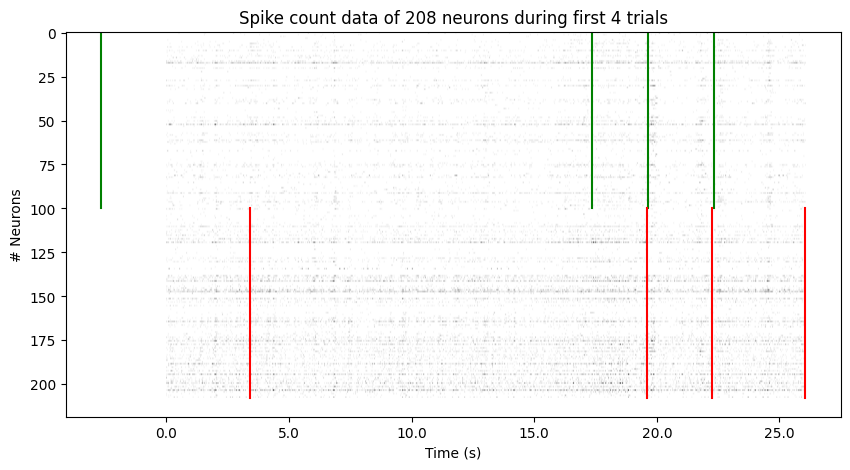

In [7]:
plt.figure(figsize=(10,5))
ax1= plt.subplot(1,1,1)
ax1.imshow(neural_data[:,Ind_first4trials[0]:Ind_first4trials[1]], aspect = 'auto', vmax = np.round(100*neural_data[:,Ind_first4trials[0]:Ind_first4trials[1]].max())/100, vmin = 0, cmap ='gray_r')
ax1.set_ylabel('# Neurons')
ax1.set_xlabel('Time (s)')
ax1.set_xticks(np.linspace(0,30*FS, 7))
ax1.set_xticklabels(np.linspace(0,30, 7))
ax1.set_title('Spike count data of 208 neurons during first 4 trials')
ax1.plot([(Trial2[0] - Time0)*FS, (Trial2[0] - Time0)*FS], [0, 100], color='green')
ax1.plot([(Trial1[0] - Time0)*FS, (Trial1[0] - Time0)*FS], [0, 100], color='green')
ax1.plot([(Trial3[0] - Time0)*FS, (Trial3[0] - Time0)*FS], [0, 100], color='green')
ax1.plot([(Trial4[0] - Time0)*FS, (Trial4[0] - Time0)*FS], [0, 100], color='green')
ax1.plot([(Trial2[1] - Time0)*FS, (Trial2[1] - Time0)*FS], [100, 208], color='red')
ax1.plot([(Trial1[1] - Time0)*FS, (Trial1[1] - Time0)*FS], [100, 208], color='red')
ax1.plot([(Trial3[1] - Time0)*FS, (Trial3[1] - Time0)*FS], [100, 208], color='red')
ax1.plot([(Trial4[1] - Time0)*FS, (Trial4[1] - Time0)*FS], [100, 208], color='red')

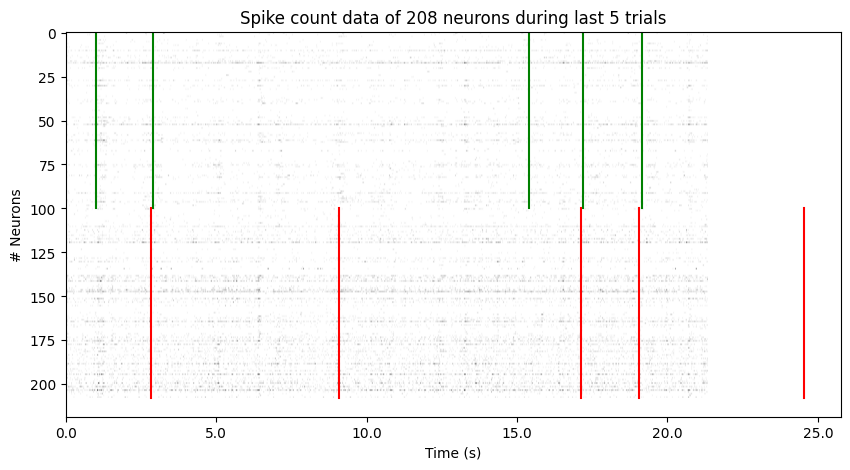

In [8]:
plt.figure(figsize=(10,5))
ax1= plt.subplot(1,1,1)
ax1.imshow(neural_data[:,Ind_last5trials[0]-FS:Ind_last5trials[1]], aspect = 'auto', vmax = np.round(100*neural_data[:,Ind_last5trials[0]-FS:Ind_last5trials[1]].max())/100, vmin = 0, cmap ='gray_r')
ax1.set_ylabel('# Neurons')
ax1.set_xlabel('Time (s)')
ax1.set_xticks(np.linspace(0,25*FS, 6))
ax1.set_xticklabels(np.linspace(0,25, 6))
ax1.set_title('Spike count data of 208 neurons during last 5 trials')
ax1.plot([FS, FS], [0, 100], color='green')
ax1.plot([(Trial4end[0]*FS - (Trial5end[0]*FS -FS)), (Trial4end[0]*FS - (Trial5end[0]*FS -FS))], [0, 100], color='green')
ax1.plot([(Trial3end[0]*FS - (Trial5end[0]*FS -FS)), (Trial3end[0]*FS - (Trial5end[0]*FS -FS))], [0, 100], color='green')
ax1.plot([(Trial2end[0]*FS - (Trial5end[0]*FS -FS)), (Trial2end[0]*FS - (Trial5end[0]*FS -FS))], [0, 100], color='green')
ax1.plot([(Trial1end[0]*FS - (Trial5end[0]*FS -FS)), (Trial1end[0]*FS - (Trial5end[0]*FS -FS))], [0, 100], color='green')
ax1.plot([(Trial5end[1]*FS - (Trial5end[0]*FS -FS)), (Trial5end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')
ax1.plot([(Trial4end[1]*FS - (Trial5end[0]*FS -FS)), (Trial4end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')
ax1.plot([(Trial3end[1]*FS - (Trial5end[0]*FS -FS)), (Trial3end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')
ax1.plot([(Trial2end[1]*FS - (Trial5end[0]*FS -FS)), (Trial2end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')
ax1.plot([(Trial1end[1]*FS - (Trial5end[0]*FS -FS)), (Trial1end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')


In [9]:
def plot_cebra(embtrain, embval, cebra_model, label):
    # plot the embedding for training set
    print('plotting the embedding for training data')
    fig = plt.figure(figsize=(15,5))
    ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
    colors = np.tile(np.arange(100),int(embtrain.shape[0]/100)+1)
    colors = colors[:len(embtrain[:,0])]
    ax1.scatter(embtrain[:,0], embtrain[:,1], embtrain[:,2], cmap = 'magma', c = colors, s=1)
    ax1.set_title("Embedding train set " + label)

    # plot the embedding for validating set
    print('plotting the embedding for validating data')
    ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
    colors = np.tile(np.arange(100),int(embval.shape[0]/100)+1)
    colors = colors[:len(embval[:,0])]
    ax2.scatter(embval[:,0], embval[:,1], embval[:,2], cmap = 'magma', c = colors, s=1)
    ax2.set_title("Embedding Valid set " + label)

    # plot the loss
    print('plotting the Loss')
    ax3 = fig.add_subplot(1,3,3)
    cebra.plot_loss(cebra_model, ax=ax3)
    ax3.set_title("Loss " + label)

## Exploring the effect of changing the time_offset

6D offset5-model with time_offsets of 1 was found to be the best when varying the dimensions (notebook 2)

5D offset5-model with time_offsets of 5 was found to be the best when varying the dimensions (notebook 2)

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset5-model',
      output_dimension=6, time_offsets=5)
Fitting the model
calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss


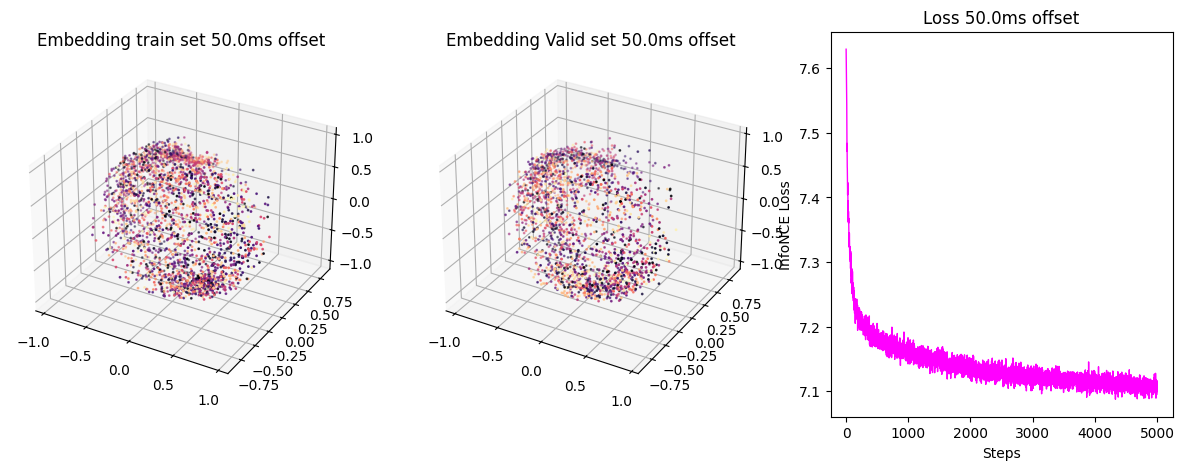

In [10]:
Output_dim = 6
Time_offsets = 5
cebra_5 = CEBRA(
    model_architecture = "offset5-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offsets, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_5)

# fit the model
print('Fitting the model')
cebra_5.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_5.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embtrain = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_5.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embval = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

plot_cebra(embtrain, embval, cebra_5, str(Time_offsets*1000/FS) + "ms offset")


CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset5-model',
      output_dimension=6, time_offsets=4)
Fitting the model
calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss


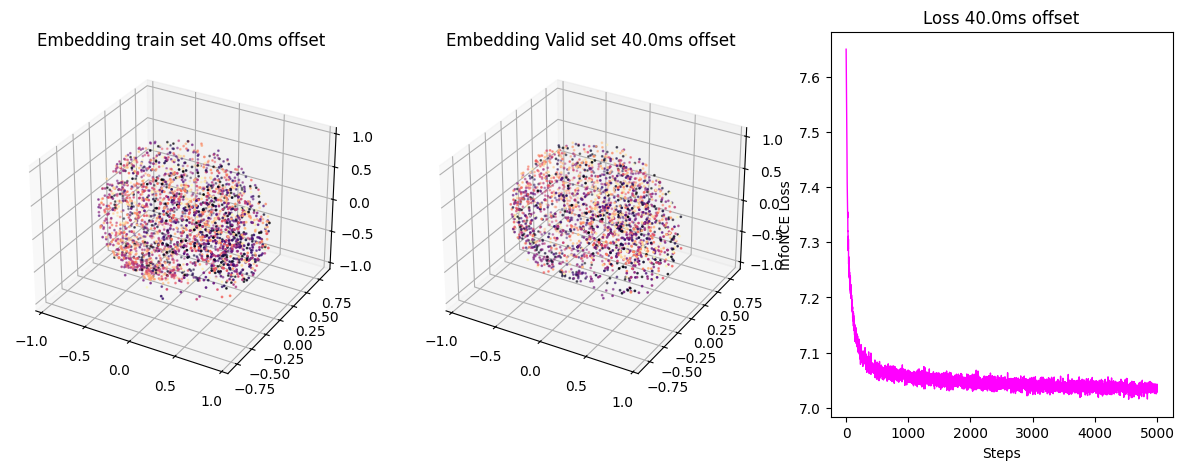

In [11]:
Output_dim = 6
Time_offsets = 4
cebra_4 = CEBRA(
    model_architecture = "offset5-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offsets, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_4)

# fit the model
print('Fitting the model')
cebra_4.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_4.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embtrain = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_4.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embval = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

plot_cebra(embtrain, embval, cebra_4, str(Time_offsets*1000/FS) + "ms offset")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset5-model',
      output_dimension=6, time_offsets=3)
Fitting the model
calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss


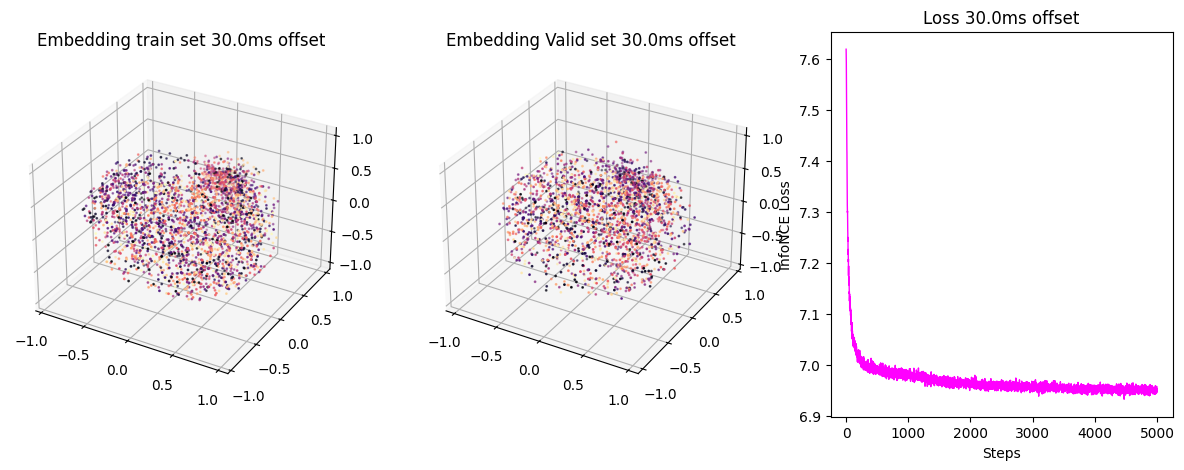

In [12]:
Output_dim = 6
Time_offsets = 3
cebra_3 = CEBRA(
    model_architecture = "offset5-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offsets, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_3)

# fit the model
print('Fitting the model')
cebra_3.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_3.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embtrain = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_3.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embval = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

plot_cebra(embtrain, embval, cebra_3, str(Time_offsets*1000/FS) + "ms offset")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset5-model',
      output_dimension=6, time_offsets=2)
Fitting the model
calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss


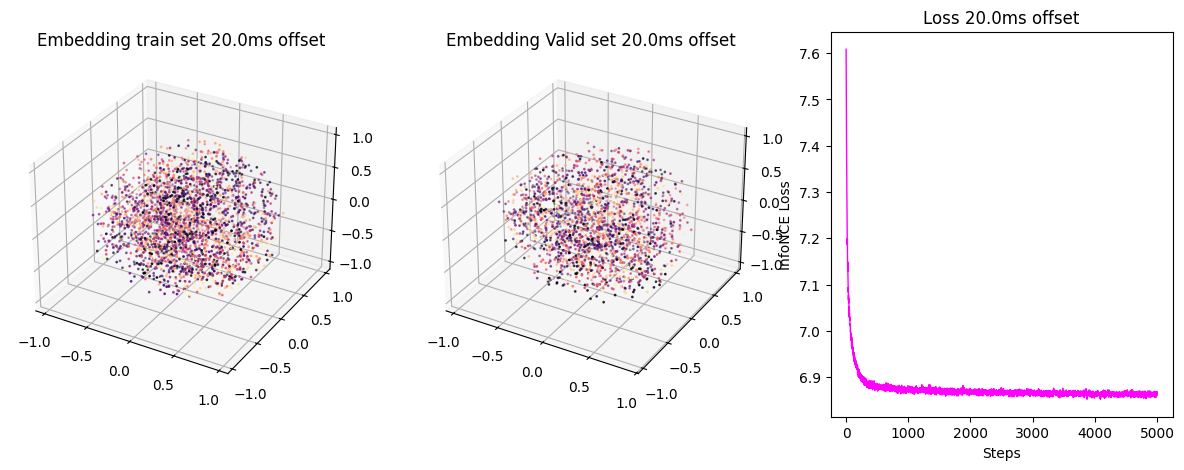

In [13]:
Output_dim = 6
Time_offsets = 2
cebra_2 = CEBRA(
    model_architecture = "offset5-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offsets, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_2)

# fit the model
print('Fitting the model')
cebra_2.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_2.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embtrain = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_2.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embval = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

plot_cebra(embtrain, embval, cebra_2, str(Time_offsets*1000/FS) + "ms offset")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset5-model',
      output_dimension=6)
Fitting the model
calculating the training embedding
calculating the validating embedding
plotting the embedding for training data
plotting the embedding for validating data
plotting the Loss


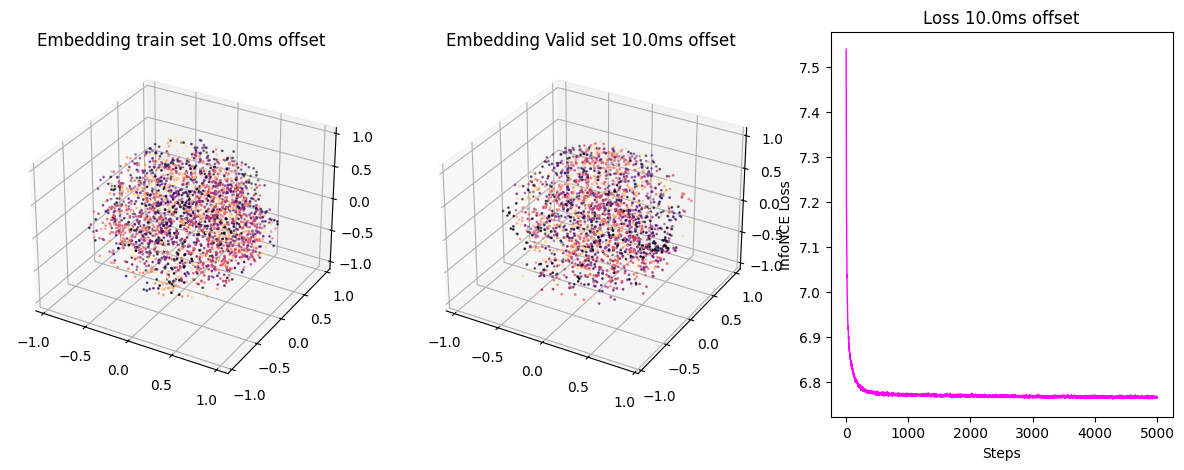

In [14]:
Output_dim = 6
Time_offsets =1
cebra_1 = CEBRA(
    model_architecture = "offset5-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = Time_offsets, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_1)

# fit the model
print('Fitting the model')
cebra_1.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_1.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embtrain = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_1.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embval = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

plot_cebra(embtrain, embval, cebra_1, str(Time_offsets*1000/FS) + "ms offset")

# Comparing models

<Axes: xlabel='Steps', ylabel='InfoNCE Loss'>

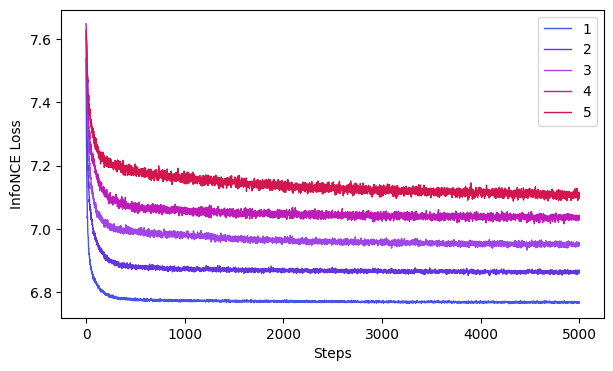

In [15]:
# compare Losses
# Labels to be used for the legend of the plot
labels = ["1","2", "3", "4", "5"]
cebra.compare_models([cebra_1, cebra_2, cebra_3, cebra_4, cebra_5], labels)

Text(0.5, 0, 'Time offsets (in steps with 1 step = 10.0 ms)')

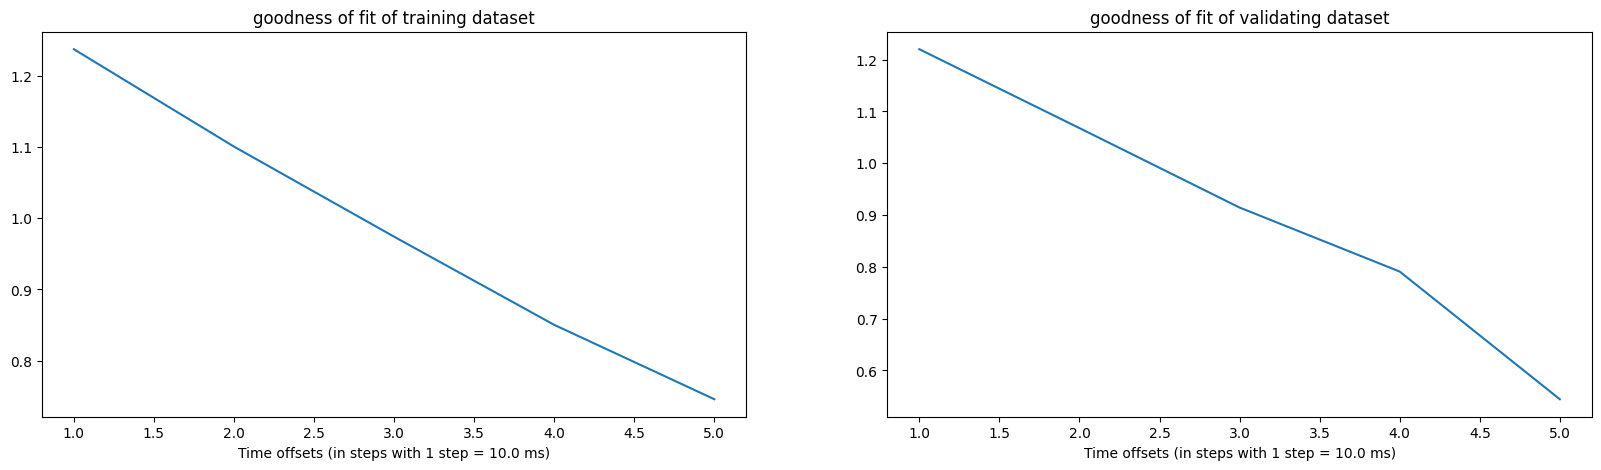

In [16]:
# Evaluate the model performance
goodness_of_fit_train = []
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_1,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_2,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_3,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_4,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_5,
                                                     train_data))

fig = plt.figure(figsize=(20,5))
ax1 = fig.add_subplot(1,2,1)
ax1.plot([1,2,3,4,5], goodness_of_fit_train)
ax1.set_title('goodness of fit of training dataset')
ax1.set_xlabel('Time offsets (in steps with 1 step = '+ str(1/FS*1000) + ' ms)')

goodness_of_fit_valid = []
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_1,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_2,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_3,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_4,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_5,
                                                     valid_data))

ax2 = fig.add_subplot(1,2,2)
ax2.plot([1,2,3,4,5], goodness_of_fit_valid)
ax2.set_title('goodness of fit of validating dataset')
ax2.set_xlabel('Time offsets (in steps with 1 step = '+ str(1/FS*1000) + ' ms)')

Time_offset =1 is the best for this dataset